# Getting Started with minicamels

This notebook introduces the `minicamels` dataset — a curated subset of the
[CAMELS-US](https://ral.ucar.edu/solutions/products/camels) large-sample
hydrometeorological dataset designed for teaching.

**What's in the dataset:**
- 50 USGS basins spanning diverse climate regions across the contiguous US
- 30 water years of daily data (WY1981–WY2010)
- Daymet-derived meteorological forcings: precipitation, temperature, solar radiation, vapor pressure
- USGS observed streamflow, normalized to mm/day
- Static catchment attributes: area, elevation, aridity, soil properties, land cover, and more

---

## Setup

**Google Colab users:** uncomment and run the cell below first.

In [1]:
# Colab only — skip if running locally
# !pip install git+https://github.com/andrbenn/minicamels.git

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from minicamels import MiniCamels

ds = MiniCamels()
print(ds)

MiniCamels(basins=50, period=1980-10-01–2010-09-30, forcing=Daymet, source=local (/home/andrbenn/workspace/minicamels/data))


---
## 1. Exploring the basin index and attributes

In [3]:
# All 50 basins
basins = ds.basins()
print(f"{len(basins)} basins")
basins

50 basins


,basin_id,basin_name
0,01013500,"Fish River near Fort Kent, Maine"
1,01580000,"DEER CREEK AT ROCKS, MD"
2,02016000,"COWPASTURE RIVER NEAR CLIFTON FORGE, VA"
3,02064000,"FALLING RIVER NEAR NARUNA, VA"
4,02221525,"MURDER CREEK BELOW EATONTON, GA"
5,02297310,HORSE CREEK NEAR ARCADIA FL
6,02298123,PRAIRIE CREEK NEAR FORT OGDEN FL
7,02371500,CONECUH RIVER AT BRANTLEY AL
8,02415000,HILLABEE CREEK NEAR HACKNEYVILLE AL
9,03504000,"NANTAHALA RIVER NEAR RAINBOW SPRINGS, NC"


In [4]:
# Static catchment attributes — one row per basin
attrs = ds.attributes()
attrs.head()

,lat,lon,elev_mean,slope_mean,area_km2,mean_prcp,mean_pet,aridity,frac_snow,q_mean,runoff_ratio,hfd_mean,baseflow_index,soil_depth_pelletier,frac_forest,lai_max
basin_id,,,,,,,,,,,,,,,,
01013500,47.23739,-68.58264,250.31,21.64152,2252.70,3.126679,1.971555,0.630559,0.313440,1.699155,0.543437,207.25,0.585226,7.404762,0.9063,4.167304
01580000,39.62997,-76.40331,174.30,12.44242,244.37,3.431728,2.527253,0.736437,0.081688,1.305300,0.380362,171.95,0.715801,1.046154,0.4241,2.511604
02016000,37.79180,-79.75949,645.04,66.42056,1194.55,3.144815,2.573820,0.818433,0.102077,1.155713,0.367498,170.30,0.497769,1.013858,0.9317,5.088656
02064000,37.12681,-78.95974,192.21,9.95686,427.77,3.095496,2.926439,0.945386,0.060601,0.929232,0.300188,168.45,0.564004,1.070644,0.9090,4.344958
02221525,33.25236,-83.48128,176.01,7.55177,490.80,3.359124,3.142409,0.935485,0.009539,0.762009,0.226848,161.00,0.529551,1.142454,0.8252,4.545543


In [5]:
# Summary statistics across the 50 basins
attrs[["area_km2", "mean_prcp", "aridity", "q_mean", "runoff_ratio"]].describe().round(2)

,area_km2,mean_prcp,aridity,q_mean,runoff_ratio
count,50.00,50.00,50.00,50.00,50.00
mean,921.47,3.47,1.06,1.86,0.45
std,1193.41,1.62,0.88,1.93,0.26
min,50.20,0.64,0.23,0.04,0.04
25%,235.88,2.67,0.67,0.85,0.28
50%,449.18,3.20,0.87,1.32,0.39
75%,1105.05,3.94,0.97,2.29,0.61
max,5318.59,8.15,5.21,9.69,1.19


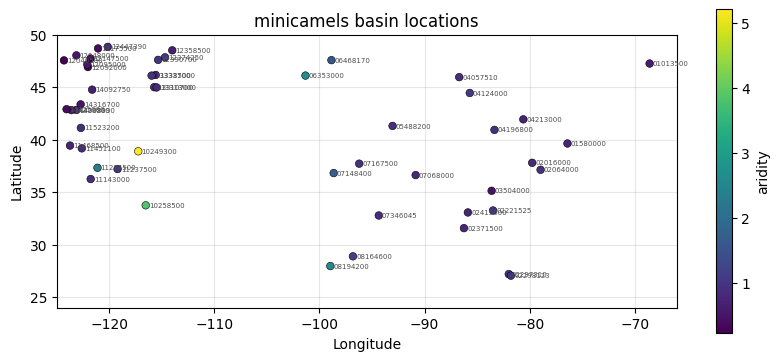

In [6]:
# Map of basin locations, coloured by aridity
# aridity = PET / P:  < 1 = energy-limited (humid),  > 1 = water-limited (arid)
ds.plot_map(color_by="aridity")
plt.show()

---
## 2. Loading a single basin

Each basin's timeseries is an `xarray.Dataset` with a `time` dimension and six variables.

In [7]:
basin_id = "01013500"  # Fish River near Fort Kent, Maine

ts = ds.load_basin(basin_id)
ts

<xarray.Dataset> Size: 351kB
Dimensions:  (time: 10957)
Coordinates:
  * time     (time) datetime64[ns] 88kB 1980-10-01 1980-10-02 ... 2010-09-30
Data variables:
    prcp     (time) float32 44kB 3.1 4.24 8.02 15.27 ... 1.57 14.67 10.05 17.14
    tmax     (time) float32 44kB 10.05 15.82 15.86 11.1 ... 18.75 20.68 20.37
    tmin     (time) float32 44kB 2.11 5.24 7.81 3.66 ... 6.46 9.51 11.75 10.5
    srad     (time) float32 44kB 192.6 206.3 165.4 159.8 ... 200.9 194.3 209.8
    vp       (time) float32 44kB 711.3 898.6 1.065e+03 ... 1.38e+03 1.28e+03
    qobs     (time) float32 44kB 0.5528 0.5626 0.5604 ... 0.694 0.8167 0.9351
Attributes:
    Conventions:  CF-1.8
    basin_id:     01013500
    basin_name:   Fish River near Fort Kent, Maine
    area_km2:     2252.7
    lat:          47.23739
    lon:          -68.58264
    huc02:        01
    forcing:      Daymet
    created:      2026-03-30
    source:       CAMELS-US (Newman et al. 2015; Addor et al. 2017)

In [ ]:
# Variables, units, and coverage
for name, var in ts.data_vars.items():
    n_nan = int(np.isnan(var.values).sum())
    pct = 100 * n_nan / len(var)
    print(f"  {name:6s}  units={var.attrs.get('units',''):10s}  missing={pct:.1f}%")

In [ ]:
# Full timeseries plot — one panel per variable
ds.plot_basin(basin_id)
plt.show()

---
## 3. Slicing by time and water year

The hydrological water year runs from **October 1 to September 30**.
Water year 2000 = Oct 1 1999 – Sep 30 2000.

In [ ]:
# One water year
wy2000 = ds.get_water_year(basin_id, water_year=2000)
print(f"WY2000: {wy2000.time.values[0]} → {wy2000.time.values[-1]}  ({len(wy2000.time)} days)")

In [ ]:
# Plot precipitation and streamflow for a single water year
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

wy2000["prcp"].plot(ax=ax1, color="steelblue", linewidth=0.8)
ax1.set_ylabel("Precipitation (mm/day)")
ax1.set_title(f"{basin_id} — Water Year 2000")

wy2000["qobs"].plot(ax=ax2, color="seagreen", linewidth=0.8)
ax2.set_ylabel("Streamflow (mm/day)")
ax2.set_xlabel("")

fig.tight_layout()
plt.show()

In [ ]:
# Or slice by date string
summer = ds.get_forcings(basin_id, start="1995-06-01", end="1995-08-31")
print(f"Summer slice: {len(summer.time)} days")

---
## 4. Comparing multiple basins

Load several basins at once and concatenate them along a `basin` dimension.

In [ ]:
# Pick a humid northeastern basin and an arid southwestern one
humid  = "01013500"  # Fish River, Maine       (aridity ~ 0.63)
arid   = "08194200"  # Frio River, Texas       (aridity ~ 2.1)

multi = ds.open_basins([humid, arid])
multi

In [ ]:
# Mean annual streamflow for each basin
q_annual = multi["qobs"].resample(time="YE").sum()

fig, ax = plt.subplots(figsize=(10, 4))
for bid in [humid, arid]:
    name = basins.set_index("basin_id").loc[bid, "basin_name"]
    q_annual.sel(basin=bid).plot(ax=ax, label=f"{bid}\n{name}")

ax.set_title("Annual streamflow: humid vs. arid basin")
ax.set_ylabel("Streamflow (mm/year)")
ax.set_xlabel("")
ax.legend(fontsize=8)
plt.show()

In [ ]:
# Mean seasonal cycle (all 50 basins)
all_basins = ds.open_basins()
seasonal_q = all_basins["qobs"].groupby("time.month").mean()

fig, ax = plt.subplots(figsize=(8, 4))
for bid in seasonal_q.basin.values:
    ax.plot(seasonal_q.month, seasonal_q.sel(basin=bid),
            color="steelblue", alpha=0.25, linewidth=0.8)

seasonal_q.mean("basin").plot(ax=ax, color="navy", linewidth=2, label="50-basin mean")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
ax.set_ylabel("Mean daily streamflow (mm/day)")
ax.set_title("Seasonal streamflow cycle — all 50 basins")
ax.legend()
plt.show()

---
## 5. Preparing data for machine learning

A common task is predicting streamflow from meteorological inputs.
Here we build a simple feature matrix `X` and target vector `y` for one basin.

In [ ]:
import pandas as pd

basin_id = "01013500"
ts = ds.load_basin(basin_id)

# Convert to a pandas DataFrame for easy manipulation
df = ts.to_dataframe().drop(columns=["spatial_ref"], errors="ignore")
df.head()

In [ ]:
# Drop rows where streamflow is missing, then split features and target
df = df.dropna(subset=["qobs"])

forcing_cols = ["prcp", "tmax", "tmin", "srad", "vp"]
X = df[forcing_cols].values   # shape: (n_days, 5)
y = df["qobs"].values         # shape: (n_days,)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Date range: {df.index[0].date()} → {df.index[-1].date()}")

In [ ]:
# Conventional train/test split at a water-year boundary
# Train: WY1981–WY2000  |  Test: WY2001–WY2010
split_date = "2000-10-01"
train_mask = df.index < split_date
test_mask  = df.index >= split_date

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"Train: {train_mask.sum()} days  |  Test: {test_mask.sum()} days")

In [ ]:
# Quick baseline: predict with mean training streamflow
y_pred_baseline = np.full_like(y_test, y_train.mean())

# Nash-Sutcliffe Efficiency (NSE) — standard metric in hydrology
# NSE = 1.0 is perfect;  NSE = 0 means model is no better than the mean
def nse(obs, sim):
    return 1 - np.sum((obs - sim) ** 2) / np.sum((obs - obs.mean()) ** 2)

print(f"Baseline NSE (mean prediction): {nse(y_test, y_pred_baseline):.3f}")
print()
print("Next step: fit a model (e.g. random forest, LSTM) and compare!")

---
## Next steps

Some things to try:

- **Add lag features** — streamflow today depends on rainfall from the past several days.
  Try adding `prcp` lagged by 1–14 days as additional columns in `X`.
- **Use catchment attributes as static inputs** — combine the time-varying forcings
  with static attributes (e.g. `area_km2`, `aridity`, `frac_forest`) to build a model
  that generalises across basins.
- **Try a sequence model** — daily hydrology has strong temporal memory.
  A rolling-window approach or an LSTM reads the data as sequences rather than
  independent daily snapshots.
- **Evaluate across all 50 basins** — train on some basins, test on held-out ones
  (regionalisation / transfer learning).